In [3]:
# ============================================================
# CELL 1: LOAD ALL RESULTS.JSON FILES FROM CHECKPOINTS FOLDER
# ============================================================
import os
import json
import glob
import pandas as pd

CHECKPOINTS_DIR = "checkpoints"

results_files = glob.glob(os.path.join(CHECKPOINTS_DIR, "*", "results.json"))
print(f"Found {len(results_files)} results files")

all_results = []
for rf in results_files:
    with open(rf) as f:
        data = json.load(f)
    all_results.append(data)

df = pd.DataFrame(all_results)

Found 15 results files


In [4]:
# ============================================================
# CELL 2: SHORTEN LONG MODEL NAMES FOR DISPLAY
# ============================================================
NAME_OVERRIDES = {
    "ensemble_efficientnet_b0_full_shufflenet_v2_full_shufflenet_v2_partial_mobilenet_v3_small_full": "ensemble_4model",
}
df["model"] = df["model"].replace(NAME_OVERRIDES)

# defines which component architectures make up each ensemble, using the SHORT name as key
ENSEMBLE_COMPONENTS = {
    "ensemble_4model": [
        ("efficientnet_b0", "full"),
        ("shufflenet_v2", "full"),
        ("shufflenet_v2", "partial"),
        ("mobilenet_v3_small", "full"),
    ]
}

df = df.sort_values(by=["test_macro_f1"], ascending=False).reset_index(drop=True)
print(df[["model", "train_mode", "test_accuracy", "test_macro_f1"]].to_string(index=False))

             model                train_mode  test_accuracy  test_macro_f1
   ensemble_4model weighted_average_ensemble       0.935000       0.937798
   efficientnet_b0                      full       0.920000       0.919714
     shufflenet_v2                      full       0.920000       0.915832
     shufflenet_v2                   partial       0.905000       0.911480
mobilenet_v3_small                      full       0.885000       0.884461
   efficientnet_b0           classifier_only       0.875000       0.884330
mobilenet_v3_small                   partial       0.860000       0.857863
   efficientnet_b0                   partial       0.870000       0.857017
     shufflenet_v2           classifier_only       0.860000       0.852714
mobilenet_v3_small           classifier_only       0.845000       0.851262
        custom_cnn full_RANDOMSPLIT_ablation       0.847308       0.844210
         wider_cnn    weighted_loss_ablation       0.840000       0.799856
        custom_cnn       

In [5]:
# ============================================================
# CELL 3: BUILD MODEL ARCHITECTURES + COMPUTE GFLOPs (non-ensemble rows first)
# ============================================================
import torch
import torch.nn as nn
from torchvision import models
from thop import profile

IMG_SIZE = 128
NUM_CLASSES = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LightCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

class WiderCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

def build_model(name, num_classes):
    if name == "mobilenet_v3_small":
        m = models.mobilenet_v3_small(weights=None)
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    elif name == "shufflenet_v2":
        m = models.shufflenet_v2_x1_0(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    elif name == "custom_cnn":
        m = LightCNN(num_classes)
    elif name == "wider_cnn":
        m = WiderCNN(num_classes)
    else:
        return None
    return m

if "gflops" not in df.columns:
    df["gflops"] = None

gflops_cache = {}  # architecture-name -> GFLOPs, populated dynamically (no hardcoding)

for idx, row in df.iterrows():
    model_name = row["model"]
    if model_name in ENSEMBLE_COMPONENTS:
        continue  # handled in Cell 4, after this cache is built

    if model_name in gflops_cache:
        df.at[idx, "gflops"] = gflops_cache[model_name]
        continue

    model = build_model(model_name, NUM_CLASSES)
    if model is None:
        print(f"Skipping unknown model: {model_name}")
        continue

    model = model.to(DEVICE).eval()
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    gflops = round((macs * 2) / 1e9, 4)

    gflops_cache[model_name] = gflops
    df.at[idx, "gflops"] = gflops
    print(f"{model_name}: {gflops} GFLOPs")

    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("\nGFLOPs cache (built dynamically, no hardcoding):", gflops_cache)

efficientnet_b0: 0.2712 GFLOPs
shufflenet_v2: 0.0991 GFLOPs
mobilenet_v3_small: 0.0416 GFLOPs
custom_cnn: 0.3377 GFLOPs
wider_cnn: 1.2794 GFLOPs

GFLOPs cache (built dynamically, no hardcoding): {'efficientnet_b0': 0.2712, 'shufflenet_v2': 0.0991, 'mobilenet_v3_small': 0.0416, 'custom_cnn': 0.3377, 'wider_cnn': 1.2794}


In [6]:
# ============================================================
# CELL 4: FILL IN ENSEMBLE INFERENCE TIME + GFLOPS (sum of component models)
# ============================================================
for idx, row in df.iterrows():
    model_name = row["model"]
    if model_name not in ENSEMBLE_COMPONENTS:
        continue

    components = ENSEMBLE_COMPONENTS[model_name]
    total_ms = 0
    total_gflops = 0

    for arch, mode in components:
        comp_run_tag = f"{arch}_{mode}"
        comp_path = os.path.join(CHECKPOINTS_DIR, comp_run_tag, "results.json")
        if os.path.exists(comp_path):
            with open(comp_path) as f:
                comp_data = json.load(f)
            total_ms += comp_data.get("inference_ms_per_image", 0)
        # pull GFLOPs from the cache built in Cell 3 -- no hardcoded values needed
        total_gflops += gflops_cache.get(arch, 0)

    df.at[idx, "inference_ms_per_image"] = round(total_ms, 3)
    df.at[idx, "gflops"] = round(total_gflops, 4)
    print(f"Updated {model_name}: inference={total_ms:.3f}ms, gflops={total_gflops:.4f}")

Updated ensemble_4model: inference=1.196ms, gflops=0.5110


In [7]:
# ============================================================
# CELL 5: FINAL COMPARISON TABLE
# ============================================================
display_cols = [
    "model", "train_mode", "test_accuracy", "test_macro_f1",
    "test_precision", "test_recall", "total_params",
    "trainable_params", "model_size_mb", "gflops", "inference_ms_per_image"
]
comparison_df = df[display_cols].copy()
for col in ["test_accuracy", "test_macro_f1", "test_precision", "test_recall"]:
    comparison_df[col] = comparison_df[col].round(4)

comparison_df = comparison_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(os.path.join(CHECKPOINTS_DIR, "comparison_table_final.csv"), index=False)
print(f"\nSaved final comparison table to {os.path.join(CHECKPOINTS_DIR, 'comparison_table_final.csv')}")

             model                train_mode  test_accuracy  test_macro_f1  test_precision  test_recall  total_params  trainable_params  model_size_mb  gflops  inference_ms_per_image
   ensemble_4model weighted_average_ensemble         0.9350         0.9378          0.9429       0.9393       8102308           8102308         30.908   0.511                   1.196
   efficientnet_b0                      full         0.9200         0.9197          0.9320       0.9227       4028044           4028044         15.366  0.2712                   0.367
     shufflenet_v2                      full         0.9200         0.9158          0.9290       0.9203       1270004           1270004          4.845  0.0991                   0.180
     shufflenet_v2                   partial         0.9050         0.9115          0.9186       0.9113       1270004            994936          4.845  0.0991                   0.185
mobilenet_v3_small                      full         0.8850         0.8845          0

In [8]:
# ============================================================
# CELL 6: BEST MODEL OVERALL + BEST PER CATEGORY
# ============================================================
best_overall = comparison_df.loc[comparison_df["test_macro_f1"].idxmax()]
print("=== Best overall (highest accuracy) ===")
print(best_overall)

non_ensemble_df = comparison_df[~comparison_df["model"].str.startswith("ensemble")]
best_lightweight = non_ensemble_df.loc[non_ensemble_df["model_size_mb"].idxmin()]
print("\n=== Smallest model (efficiency contribution) ===")
print(best_lightweight)

comparison_df["f1_per_mb"] = comparison_df["test_macro_f1"] / comparison_df["model_size_mb"]
best_tradeoff = comparison_df.loc[comparison_df["f1_per_mb"].idxmax()]
print("\n=== Best accuracy-per-MB tradeoff ===")
print(best_tradeoff)

=== Best overall (highest accuracy) ===
model                               ensemble_4model
train_mode                weighted_average_ensemble
test_accuracy                                 0.935
test_macro_f1                                0.9378
test_precision                               0.9429
test_recall                                  0.9393
total_params                                8102308
trainable_params                            8102308
model_size_mb                                30.908
gflops                                        0.511
inference_ms_per_image                        1.196
Name: 0, dtype: object

=== Smallest model (efficiency contribution) ===
model                                    custom_cnn
train_mode                full_RANDOMSPLIT_ablation
test_accuracy                                0.8473
test_macro_f1                                0.8442
test_precision                               0.8468
test_recall                                  0.8483
tot

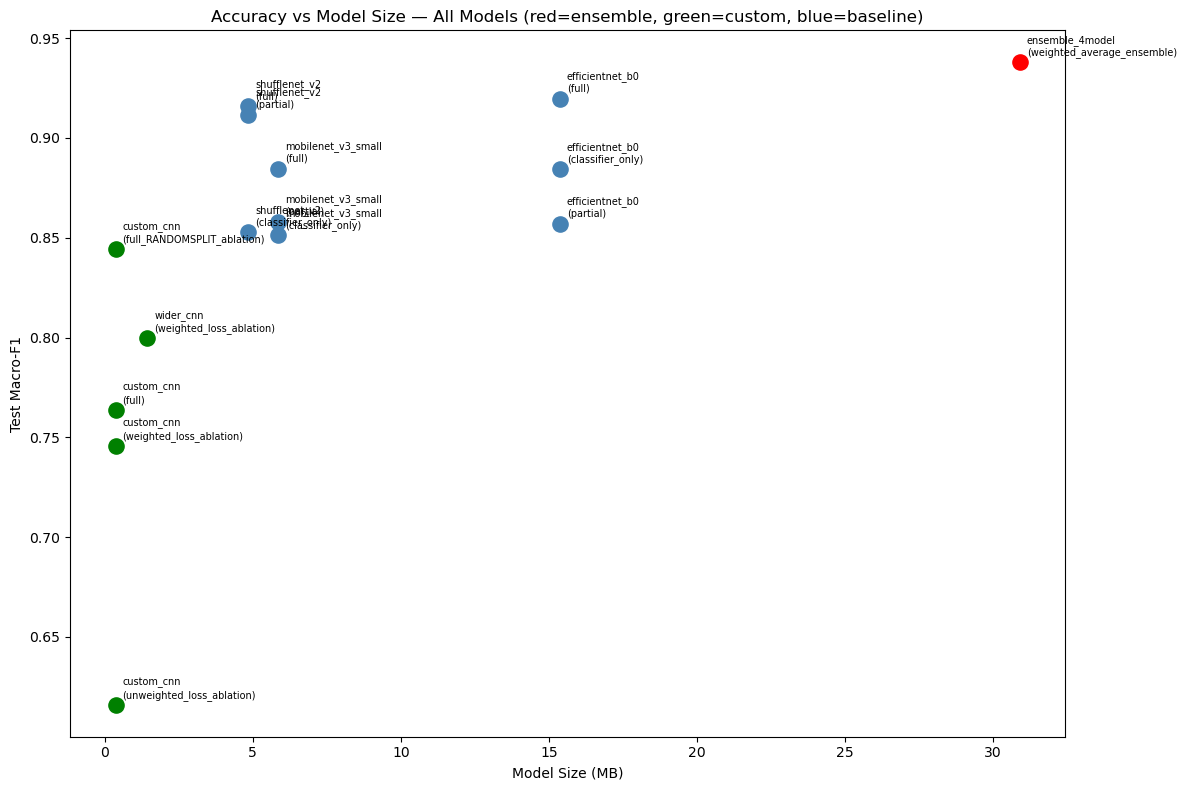

In [9]:
# ============================================================
# CELL 7: VISUALIZE — ACCURACY vs MODEL SIZE (all models incl. ensemble)
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
for _, row in comparison_df.iterrows():
    color = "red" if row["model"].startswith("ensemble") else ("green" if row["model"] in ["custom_cnn", "wider_cnn"] else "steelblue")
    ax.scatter(row["model_size_mb"], row["test_macro_f1"], s=120, color=color)
    ax.annotate(f"{row['model']}\n({row['train_mode']})",
                (row["model_size_mb"], row["test_macro_f1"]),
                fontsize=7, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Model Size (MB)")
ax.set_ylabel("Test Macro-F1")
ax.set_title("Accuracy vs Model Size — All Models (red=ensemble, green=custom, blue=baseline)")
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, "accuracy_vs_size_final.png"), dpi=300)
plt.show()

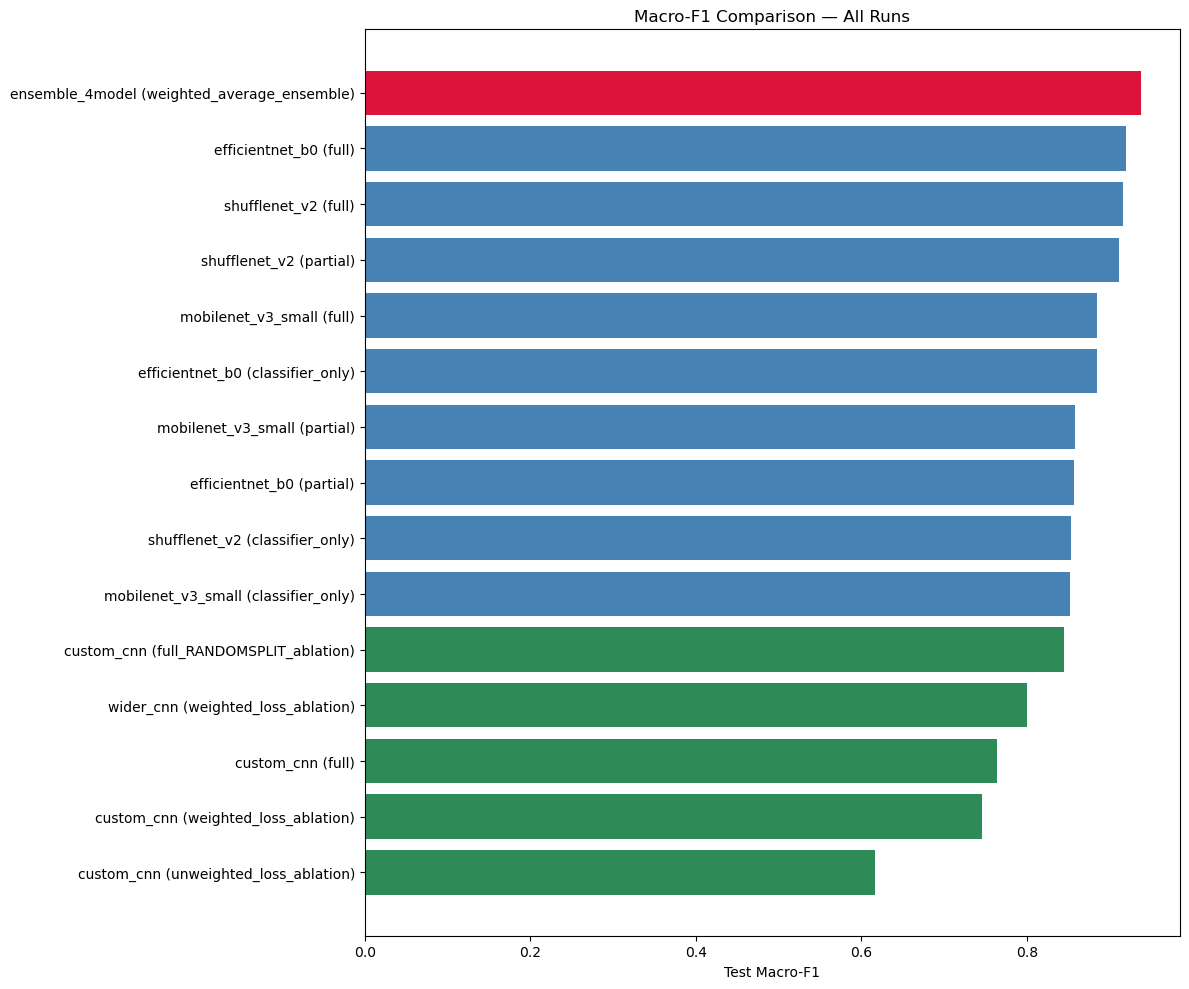

In [10]:
# ============================================================
# CELL 8: BAR CHART — MACRO-F1 ACROSS ALL RUNS
# ============================================================
comparison_df["run_label"] = comparison_df["model"] + " (" + comparison_df["train_mode"] + ")"

plt.figure(figsize=(12, 10))
sorted_df = comparison_df.sort_values("test_macro_f1")
colors = ["crimson" if m.startswith("ensemble") else ("seagreen" if m in ["custom_cnn", "wider_cnn"] else "steelblue")
          for m in sorted_df["model"]]
plt.barh(sorted_df["run_label"], sorted_df["test_macro_f1"], color=colors)
plt.xlabel("Test Macro-F1")
plt.title("Macro-F1 Comparison — All Runs")
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, "macro_f1_comparison_final.png"), dpi=300)
plt.show()

In [11]:
# ============================================================
# CELL 9: PER-CLASS RESULTS FOR THE BEST MODEL
# ============================================================
import numpy as np

best_model_name = best_overall["model"]
best_train_mode = best_overall["train_mode"]

# find the actual run_tag folder (reverse-lookup, since ensemble name was shortened)
if best_model_name in ENSEMBLE_COMPONENTS:
    best_run_tag = "best_ensemble"   # matches the folder your ensemble script saved to
else:
    best_run_tag = f"{best_model_name}_{best_train_mode}"

best_run_dir = os.path.join(CHECKPOINTS_DIR, best_run_tag)
pred_log_path = os.path.join(best_run_dir, "test_predictions_log.csv")

print(f"Best model: {best_model_name} ({best_train_mode}) -> looking in {best_run_dir}")

if os.path.exists(pred_log_path):
    pred_log_df = pd.read_csv(pred_log_path)
else:
    print(f"WARNING: no test_predictions_log.csv found for {best_run_tag}.")
    print("This file is only generated by the standalone per-model prediction script — run that for this model first if needed.")
    pred_log_df = None

Best model: ensemble_4model (weighted_average_ensemble) -> looking in checkpoints/best_ensemble


In [12]:
print("comparison_df" in dir())
print("best_overall" in dir())

True
True


=== PER-CLASS RESULTS (Best Model) ===
                                  precision  recall  f1-score  support
Aloe Vera Disease                    1.0000  1.0000    1.0000   11.000
Aloe Vera Dried                      1.0000  1.0000    1.0000    9.000
Aloe Vera Mature Healthy             1.0000  1.0000    1.0000    9.000
Aloe Vera Young Healthy              1.0000  1.0000    1.0000    8.000
Azadirachta Indica Chlorotic         0.8000  0.8889    0.8421   18.000
Azadirachta Indica Disease           0.8667  0.7222    0.7879   18.000
Azadirachta Indica Healthy           0.9583  1.0000    0.9787   23.000
Hibiscus Rosa Sinensis Chlorotic     1.0000  1.0000    1.0000   12.000
Hibiscus Rosa Sinensis Disease       1.0000  0.6667    0.8000    9.000
Hibiscus Rosa Sinensis Healthy       0.9091  1.0000    0.9524   10.000
Kalanchoe Pinnata Chlorotic          0.9000  1.0000    0.9474    9.000
Kalanchoe Pinnata Disease            0.8182  0.8182    0.8182   11.000
Kalanchoe Pinnata Healthy            0

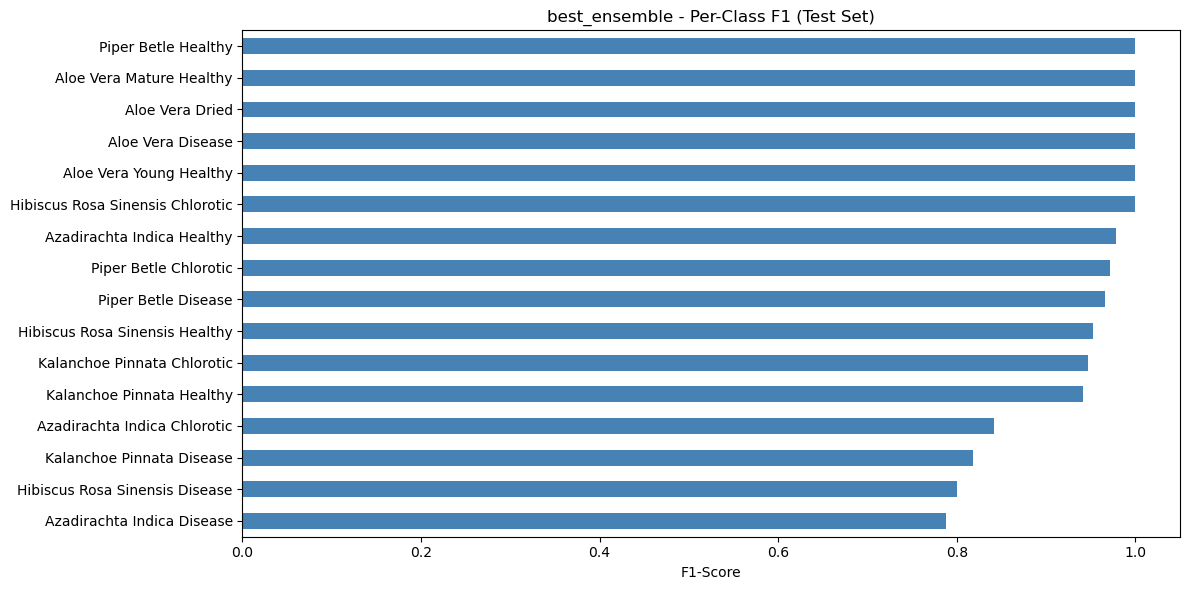

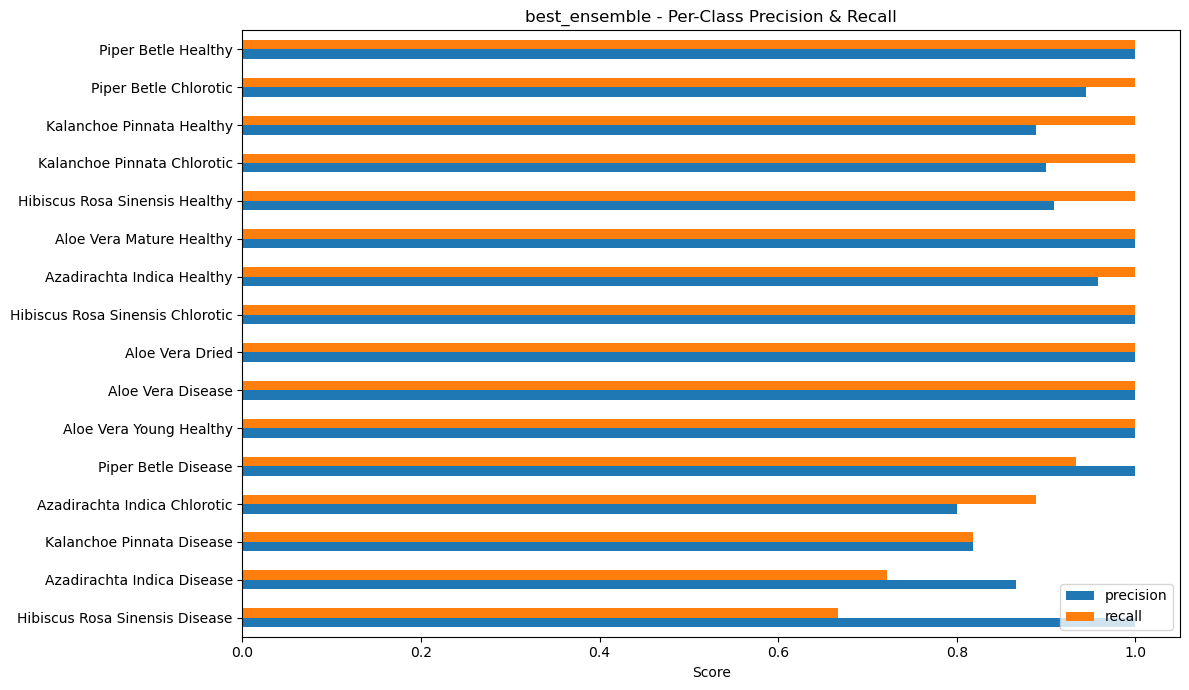

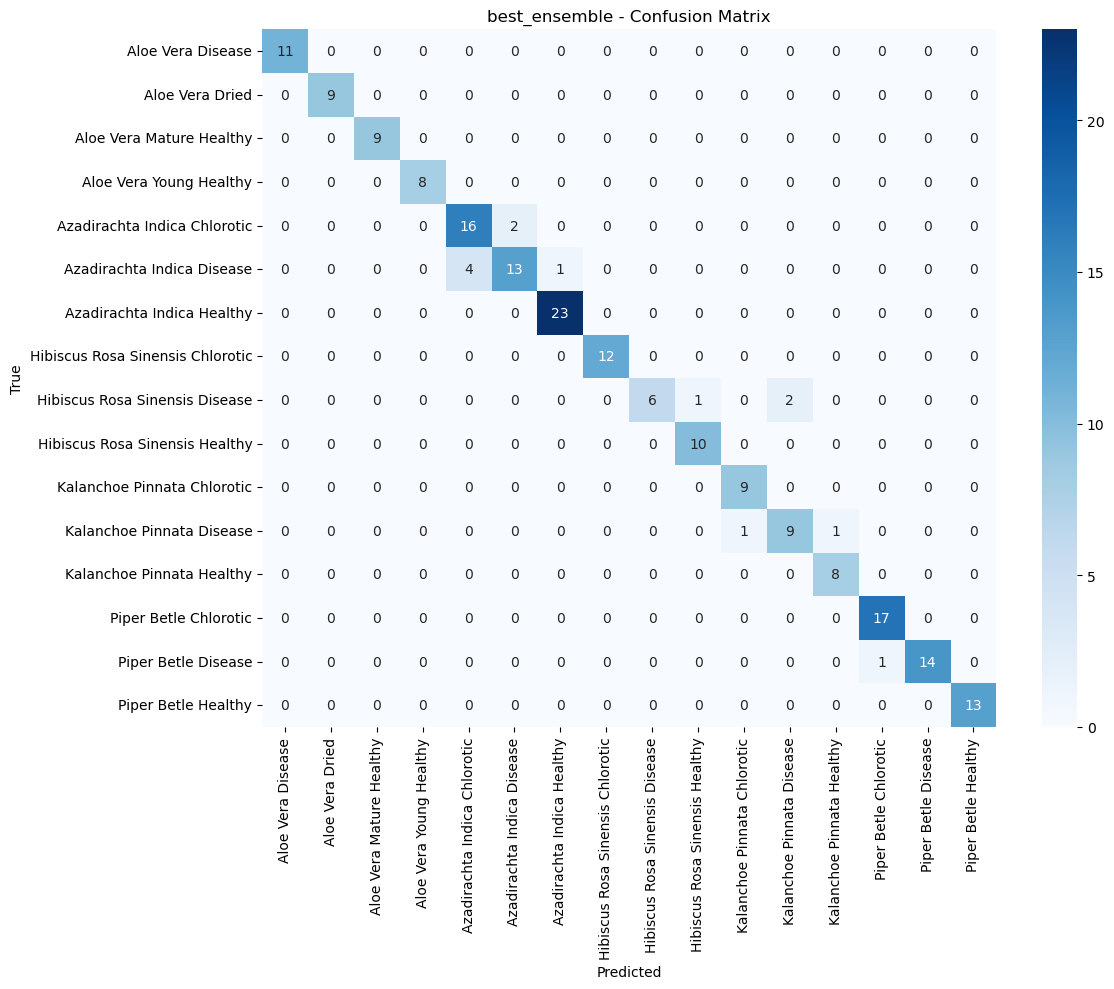

In [13]:
# ============================================================
# CELL 10: PER-CLASS PRECISION/RECALL/F1 + CONFUSION MATRIX (best model)
# ============================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

if pred_log_df is not None:
    class_names = sorted(pred_log_df["true_class"].unique())
    y_true = pred_log_df["true_class"]
    y_pred = pred_log_df["predicted_class"]

    report_dict = classification_report(y_true, y_pred, labels=class_names, target_names=class_names, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose().round(4)
    print("=== PER-CLASS RESULTS (Best Model) ===")
    print(report_df)

    report_df.to_csv(os.path.join(best_run_dir, "per_class_report.csv"))

    # per-class F1 bar chart
    per_class_f1 = report_df.iloc[:len(class_names)]["f1-score"]
    plt.figure(figsize=(12, 6))
    per_class_f1.sort_values().plot(kind="barh", color="steelblue")
    plt.xlabel("F1-Score")
    plt.title(f"{best_run_tag} - Per-Class F1 (Test Set)")
    plt.tight_layout()
    plt.savefig(os.path.join(best_run_dir, "per_class_f1.png"), dpi=300)
    plt.show()

    # per-class precision AND recall side-by-side
    pr_df = report_df.iloc[:len(class_names)][["precision", "recall"]].sort_values("recall")
    pr_df.plot(kind="barh", figsize=(12, 7))
    plt.xlabel("Score")
    plt.title(f"{best_run_tag} - Per-Class Precision & Recall")
    plt.tight_layout()
    plt.savefig(os.path.join(best_run_dir, "per_class_precision_recall.png"), dpi=300)
    plt.show()

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"{best_run_tag} - Confusion Matrix")
    plt.xticks(rotation=90); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(best_run_dir, "confusion_matrix.png"), dpi=300)
    plt.show()

Total misclassified: 13 / 200


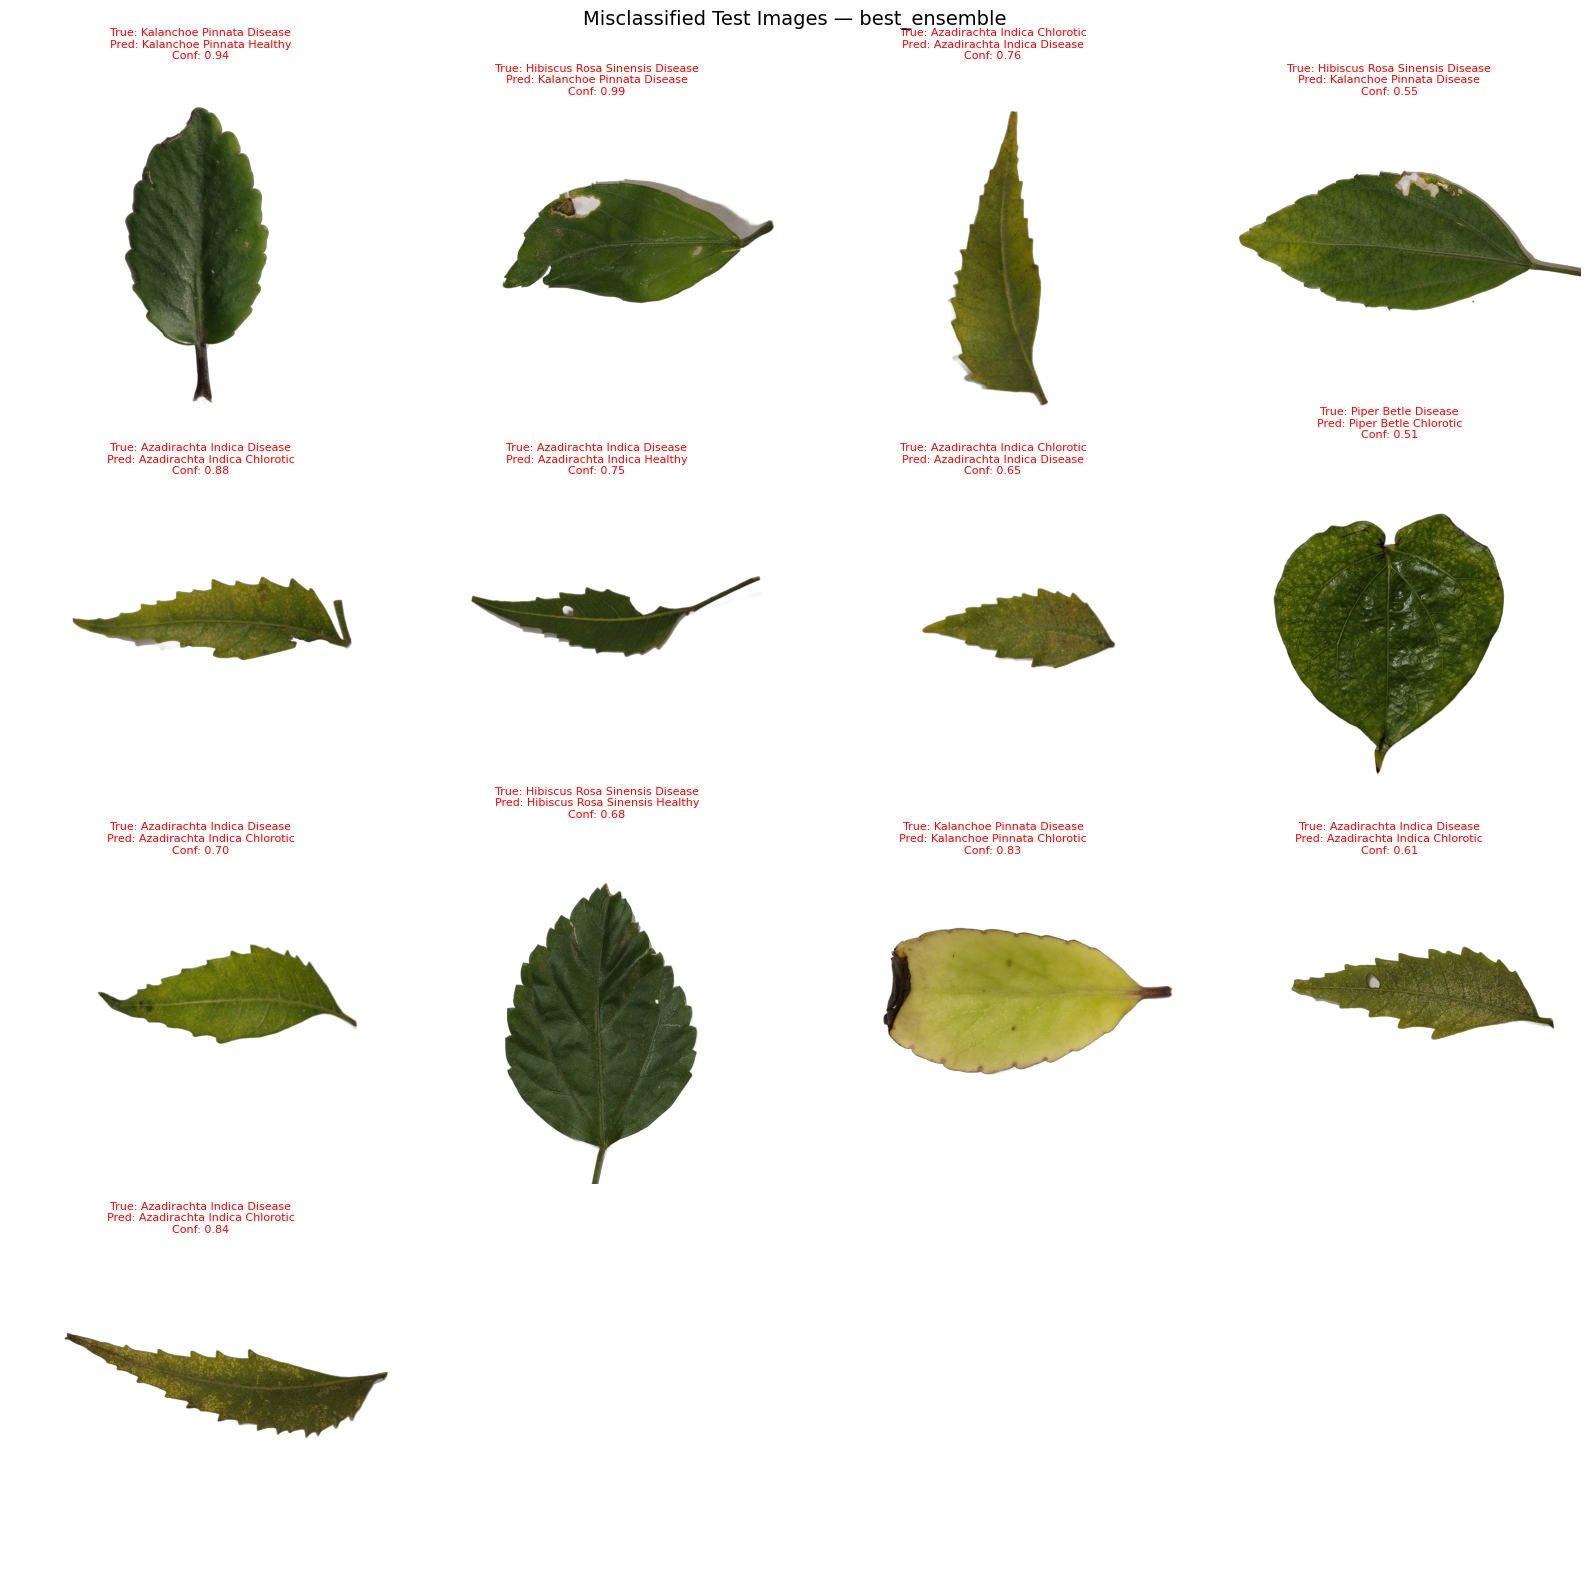

In [14]:
# ============================================================
# CELL 11: VISUALIZE MISCLASSIFIED IMAGES FOR THE BEST MODEL
# ============================================================
import matplotlib.image as mpimg

if pred_log_df is not None:
    misclassified = pred_log_df[~pred_log_df["correct"]]
    print(f"Total misclassified: {len(misclassified)} / {len(pred_log_df)}")

    N_SHOW = 16
    if len(misclassified) > 0:
        sample_misclass = misclassified.sample(min(N_SHOW, len(misclassified)), random_state=42)

        n_cols = 4
        n_rows = (len(sample_misclass) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
        axes = axes.flatten()

        for i, (_, row) in enumerate(sample_misclass.iterrows()):
            img = mpimg.imread(row["image_path"])
            axes[i].imshow(img)
            axes[i].set_title(f"True: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']:.2f}",
                               fontsize=8, color="red")
            axes[i].axis("off")

        for j in range(i + 1, len(axes)):
            axes[j].axis("off")

        plt.suptitle(f"Misclassified Test Images — {best_run_tag}", fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(best_run_dir, "misclassified_samples.png"), dpi=300)
        plt.show()
    else:
        print("No misclassified images — perfect test accuracy for this model.")

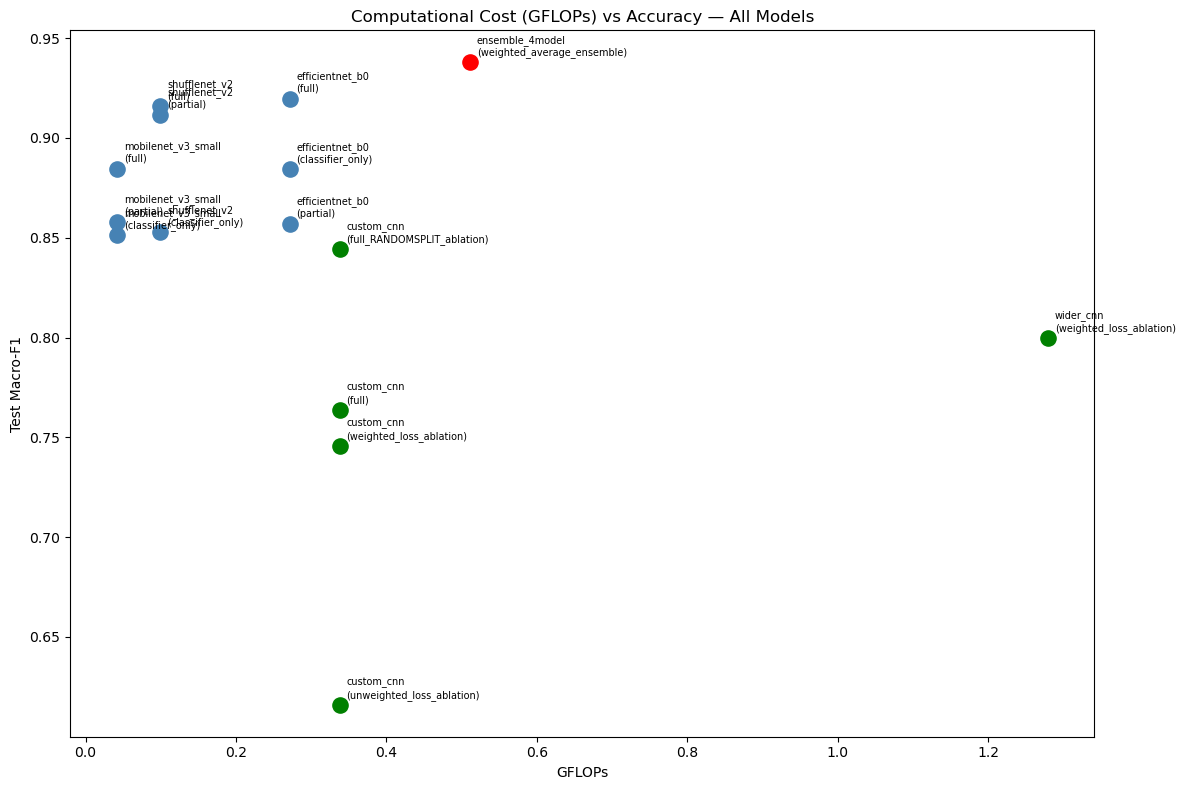

In [15]:
# ============================================================
# CELL 12: EFFICIENCY VISUALIZATION — GFLOPs vs ACCURACY (all models)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))
for _, row in comparison_df.iterrows():
    color = "red" if row["model"].startswith("ensemble") else ("green" if row["model"] in ["custom_cnn", "wider_cnn"] else "steelblue")
    ax.scatter(row["gflops"], row["test_macro_f1"], s=120, color=color)
    ax.annotate(f"{row['model']}\n({row['train_mode']})",
                (row["gflops"], row["test_macro_f1"]),
                fontsize=7, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("GFLOPs")
ax.set_ylabel("Test Macro-F1")
ax.set_title("Computational Cost (GFLOPs) vs Accuracy — All Models")
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINTS_DIR, "gflops_vs_accuracy_final.png"), dpi=300)
plt.show()

In [16]:
# ============================================================
# COMPARISON TABLE (run after df has model/gflops/inference_ms filled in)
# ============================================================
display_cols = [
    "model", "train_mode", "test_accuracy", "test_macro_f1",
    "test_precision", "test_recall", "total_params",
    "trainable_params", "model_size_mb", "gflops", "inference_ms_per_image"
]
comparison_df = df[display_cols].copy()
for col in ["test_accuracy", "test_macro_f1", "test_precision", "test_recall"]:
    comparison_df[col] = comparison_df[col].round(4)

comparison_df = comparison_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(os.path.join(CHECKPOINTS_DIR, "comparison_table_final.csv"), index=False)
print(f"\nSaved to {os.path.join(CHECKPOINTS_DIR, 'comparison_table_final.csv')}")

             model                train_mode  test_accuracy  test_macro_f1  test_precision  test_recall  total_params  trainable_params  model_size_mb  gflops  inference_ms_per_image
   ensemble_4model weighted_average_ensemble         0.9350         0.9378          0.9429       0.9393       8102308           8102308         30.908   0.511                   1.196
   efficientnet_b0                      full         0.9200         0.9197          0.9320       0.9227       4028044           4028044         15.366  0.2712                   0.367
     shufflenet_v2                      full         0.9200         0.9158          0.9290       0.9203       1270004           1270004          4.845  0.0991                   0.180
     shufflenet_v2                   partial         0.9050         0.9115          0.9186       0.9113       1270004            994936          4.845  0.0991                   0.185
mobilenet_v3_small                      full         0.8850         0.8845          0